# IIA 2024 - Aprendizaje Automatizado

## Introducción a Jupyter Notebooks y Generación de Datos

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Diagonales

Generar n datos con d inputs:

  - n/2 pertenecientes a la categoría 0. Esta clase corresponde a puntos generados al azar, provenientes de una distribución normal, con centro en el (-1, -1, -1, ... , -1) y matriz de covarianza diagonal, con desviación estándar igual a C * SQRT(d).
  - n/2 pertenecientes a la categoría 1. Esta clase corresponde a puntos generados al azar, provenientes de una distribución normal, con centro en el (1, 1, 1, ... ,1) y matriz de covarianza diagonal, con desviación estándar igual a C * SQRT(d).


In [3]:
def diagonales(d: int, C: float, n: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Genera sampleos de dos gausianas d-dimensionales en posición diagonal
    (una respecto a la otra), con dispersión C * sqrt(d).
    Cada sampleo posee n/2 puntos.

    Argumentos:
        d: número de dimensiones
        C: constante de ajuste de dispersión
        n: número de ejemplos a generar

    Retorna:
        X: matriz con d columnas y n filas de datos
        y: arreglo de n elementos con las clases correspondientes
            a cada fila de datos
    """

    mid = n // 2
    sigma = C * np.sqrt(d)
    cov = (sigma**2) * np.eye(d)

    sample0 = np.random.multivariate_normal(-np.ones(d), cov, mid)
    sample1 = np.random.multivariate_normal(np.ones(d), cov, mid)

    X = np.vstack([sample0, sample1])
    y = np.concatenate((np.zeros(mid), np.ones(mid)))
    
    return X, y

Verificamos ahora los datos generados, mostrándolos con matplotlib.pyplot

/tmp/ipykernel_3797/2011498530.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


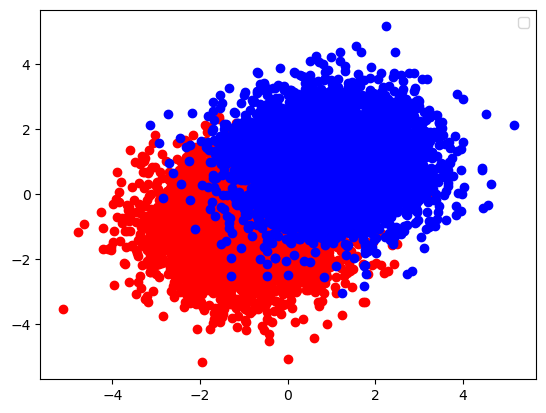

In [6]:
diag_X, diag_y = diagonales(2, 0.75, 10000)

plt.scatter(diag_X[diag_y == 0, 0], diag_X[diag_y == 0, 1], color='red')
plt.scatter(diag_X[diag_y == 1, 0], diag_X[diag_y == 1, 1], color='blue')
plt.legend()
plt.show()

## Paralelas

Igual al punto anterior, pero las distribuciones tienen centro en el ( 1, 0, 0, .... , 0 ) y en el ( -1, 0, 0, .... , 0 ), respectivamente y la desviación estandar es igual a C independientemente de d.

In [7]:
def paralelas(d: int, C: float, n: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Genera muestreos de dos gaussianas d-dimensionales distribuidas paralelamente.
    """
    mid = n // 2
    cov = (C**2) * np.eye(d)

    mean0, mean1 = np.zeros(d), np.zeros(d)
    mean0[0] = -1
    mean1[0] = 1

    sample0 = np.random.multivariate_normal(mean0, cov, mid)
    sample1 = np.random.multivariate_normal(mean1, cov, mid)
    
    X = np.vstack([sample0, sample1])
    y = np.concatenate((np.zeros(mid), np.ones(mid)))
    
    return X, y

/tmp/ipykernel_3797/392865038.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


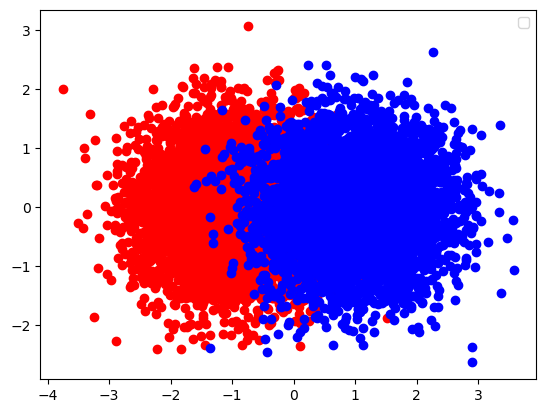

In [8]:
par_X, par_y = paralelas(2, 0.75, 10000)

plt.scatter(par_X[par_y == 0, 0], par_X[par_y == 0, 1], color='red')
plt.scatter(par_X[par_y == 1, 0], par_X[par_y == 1, 1], color='blue')
plt.legend()
plt.show()

## Espirales

Generar n datos. De los n puntos generados, n/2 deben pertenecer a cada clase.

Los datos tienen 2 inputs, x e y, que corresponden a puntos generados al azar con una distribución UNIFORME (en dicho sistema de referencia x-y) dentro de un circulo de radio 1.

El output es binario, correspondiendo la clase 0 a los puntos que se encuentran entre las curvas ro = theta/4pi y ro = (theta + pi)/4pi (en polares) y la clase 1 al resto.

In [19]:
def espirales(n: int) -> Tuple[np.ndarray, np.ndarray]:
    """
    Genera dos espirales entrelazadas con distribucion unfirome.
    """
    mid = n // 2
    
    def get_class_points(class_label: int, count: int) -> np.ndarray:
        points = []

        while len(points) < count:
            x = np.random.uniform(-1, 1, count)
            y = np.random.uniform(-1, 1, count)
            r = np.sqrt(x**2 + y**2)
            
            inside_circle = (r > 0) & (r <= 1)
            x, y, r = x[inside_circle], y[inside_circle], r[inside_circle]
            
            theta = np.arctan2(y, x)
            theta = np.where(theta < 0, theta + 2 * np.pi, theta)
            
            if class_label == 0:
                m1 = ((theta - 2*np.pi)/(4*np.pi) <= r) & (r <= (theta - np.pi)/(4*np.pi))
                m2 = (theta/(4*np.pi) <= r) & (r <= (theta + np.pi)/(4*np.pi))
                m3 = ((theta + 2*np.pi)/(4*np.pi) <= r) & (r <= (theta + 3*np.pi)/(4*np.pi))
                valid_mask = m1 | m2 | m3
            else:
                m1 = ((theta - np.pi)/(4*np.pi) <= r) & (r <= theta/(4*np.pi))
                m2 = ((theta + np.pi)/(4*np.pi) <= r) & (r <= (theta + 2*np.pi)/(4*np.pi))
                m3 = ((theta + 3*np.pi)/(4*np.pi) <= r) & (r <= (theta + 4*np.pi)/(4*np.pi))
                valid_mask = m1 | m2 | m3
                
            x_valid, y_valid = x[valid_mask], y[valid_mask]
            points.extend(np.column_stack((x_valid, y_valid)).tolist())
            
        return np.array(points[:count])

    X0 = get_class_points(class_label=0, count=mid)
    X1 = get_class_points(class_label=1, count=mid)
    
    X = np.vstack([X0, X1])
    y = np.concatenate((np.zeros(mid), np.ones(mid)))
    
    return X, y

/tmp/ipykernel_3797/1477754326.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


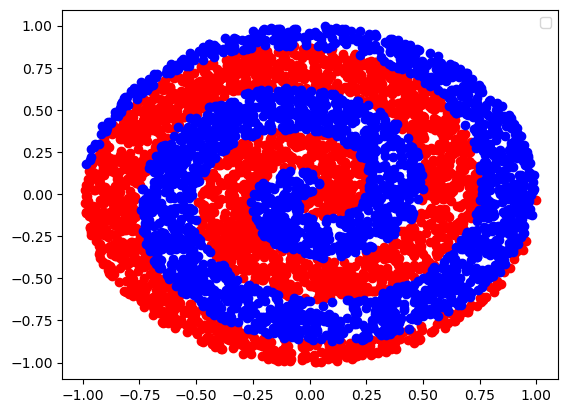

In [20]:
esp_x, esp_y = espirales(5000)

plt.scatter(esp_x[esp_y == 0, 0], esp_x[esp_y == 0, 1], color='red')
plt.scatter(esp_x[esp_y == 1, 0], esp_x[esp_y == 1, 1], color='blue')
plt.legend()
plt.show()